## Project Aim

The capstone question is:

> Can machine learning models predict whether a patient with diabetes will be readmitted to the hospital within 30 days, and does HbA1c measurement improve that prediction?

This is a predictive modeling question, not a causal claim. If a model predicts better, that does not prove that HbA1c testing causes lower readmission.


## 1. Data Source

The dataset is the UCI **Diabetes 130-US Hospitals for Years 1999-2008** dataset, associated with:

Strack, Beata, DeShazo, Jonathan P., Gennings, Chris, Olmo, Juan L., Ventura, Sebastian, Cios, Krzysztof J., and Clore, John N. "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records." BioMed Research International, 2014. https://doi.org/10.1155/2014/781670

The dataset is de-identified but still represents sensitive patient-related health information. Use it only for educational analysis and do not make patient-care recommendations from this project. The data is downloadable at https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008


In [1]:

import warnings
from pathlib import Path

import pandas as pd
from ucimlrepo import fetch_ucirepo

pd.set_option("display.max_colwidth", None)

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "diabetes_130_us_hospitals.csv"

if data_path.exists():
    # Use the local cached copy when available, avoiding an internet fetch.
    df = pd.read_csv(data_path, low_memory=False)
    df_orig = None
else:
    # Fetch from UCI only if the local copy does not exist yet.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
        df_orig = fetch_ucirepo(id=296)
    df = df_orig.data.original.copy()
    df.to_csv(data_path, index=False)

# Use one encounter per patient, matching the paper's first-encounter cohort.
# The ID columns are stored in the original dataframe, not in df_orig.data.features.
df_first = (
    df.sort_values("encounter_id")
    .drop_duplicates("patient_nbr", keep="first")
    .copy()
)

X = df_first.drop(columns=["readmitted", "encounter_id", "patient_nbr"])
y = df_first[["readmitted"]]

print(X.shape)
print(y.shape)


(71518, 47)
(71518, 1)


In [2]:
# Metadata and variable descriptions.
if df_orig is not None:
    display(df_orig.metadata)
else:
    print("Using cached data from disk; UCI metadata was not fetched in this run.")

Using cached data from disk; UCI metadata was not fetched in this run.


In [3]:
# Display the variables table with wrapped descriptions.
if df_orig is not None:
    display(
        df_orig.variables.style.set_properties(
            subset=["description"],
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "500px",
            },
        )
    )
else:
    print("Using cached data from disk; UCI variable descriptions were not fetched in this run.")

Using cached data from disk; UCI variable descriptions were not fetched in this run.


In [4]:
# Display the target variable distribution.
print(y.value_counts())

readmitted
NO            42985
>30           22240
<30            6293
Name: count, dtype: int64


In [5]:
# Display the first few rows of the features.
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
8,Caucasian,Female,[80-90),NaN,2,1,4,13,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
9,Caucasian,Female,[90-100),NaN,3,3,4,12,NaN,InternalMedicine,...,No,No,Steady,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
10,AfricanAmerican,Female,[40-50),NaN,1,1,7,9,NaN,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes
5,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes


In [6]:
# Display the number of unique values in each feature.
X.nunique()

race                          5
gender                        3
age                          10
weight                        9
admission_type_id             8
discharge_disposition_id     26
admission_source_id          17
time_in_hospital             14
payer_code                   17
medical_specialty            70
num_lab_procedures          116
num_procedures                7
num_medications              75
number_outpatient            33
number_emergency             18
number_inpatient             13
diag_1                      696
diag_2                      725
diag_3                      758
number_diagnoses             16
max_glu_serum                 3
A1Cresult                     3
metformin                     4
repaglinide                   4
nateglinide                   4
chlorpropamide                4
glimepiride                   4
acetohexamide                 2
glipizide                     4
glyburide                     4
tolbutamide                   2
pioglita


## 2. Target Variable and Initial Feature Selection

For this we will use the paper as a guideline, as the authors are domain experts and have already done a lot of work to understand the dataset and its features. The paper's main finding is that HbA1c measurement is associated with lower readmission rates. We will start with a simple baseline model using a limited set of features that are clinically relevant and available at admission time. This will allow us to establish a clear baseline for comparison before adding more complex features or models.

The original `readmitted` variable (*y* in our code) has three categories: `<30`, `>30`, and `NO`. For this project, the modeling objective is to predict whether a patient is readmitted within 30 days of discharge. Therefore, the target was converted into a binary variable. Encounters with `readmitted == "<30"` were coded as `1`, representing 30-day readmission. Encounters with `readmitted == ">30"` or `readmitted == "NO"` were coded as `0`, representing no 30-day readmission. We will use the same encoding.

The initial feature set was intentionally restricted to support a clear and interpretable baseline model. Because the goal is to focus on information that would be available at or near the time of admission, variables that are only known at the end of the hospital visit were excluded. This helps avoid data leakage, where the model would use information that would not realistically be available when making an admission-time prediction.

Several variables were removed before modeling because of missingness or high complexity. The `weight` variable was excluded because it is missing for approximately 97% of encounters. The `payer_code` variable was also removed because it is missing for approximately 52% of records. The `medical_specialty` variable was excluded from the initial model because it has many distinct categories and substantial missingness, which would add complexity to the baseline model.

The diagnosis variables `diag_1`, `diag_2`, and `diag_3` contain many distinct ICD-9 diagnosis codes (e.g. 716 for `diag_1`. Using the raw codes directly would create a sparse and difficult-to-interpret feature space. To reduce this complexity, the diagnosis codes were grouped into broader clinical categories. This grouping follows the approach used in the published study associated with the dataset, where diagnosis codes were collapsed into clinically meaningful groups. Since that grouping reflects domain-informed medical categories, it provides a defensible way to simplify the diagnosis features while preserving important clinical information.

## Initial Variables and Encoding Plan

The target variable will be `readmitted_30`, created from the original `readmitted` variable:

| Original variable | Encoding |
|---|---|
| `readmitted` | `1` if `<30`; `0` if `>30` or `NO` |

The initial feature set will be restricted to variables that are available at or near admission and that do not introduce excessive missingness or high-cardinality raw codes.

| Original variable | New model variable | Encoding / transformation                                                                           |
|---|---|-----------------------------------------------------------------------------------------------------|
| `age` | `age_group` | Group into `<30`, `30-60`, and `60-100`, following the published study’s grouped age structure.     |
| `race` | `race_group` | Group as `African American`, `Caucasian`, `Other`, and `Missing`.                                   |
| `gender` | `gender` | One-hot encode categorical values. Records with unknown/invalid gender can be removed if very rare. |
| `admission_type_id` | `admission_type_id` | Treat as categorical and one-hot encode.                                                            |
| `admission_source_id` | `admission_source_group` | Group into `Emergency`, `Physician referral`, and `Other`, then one-hot encode.                     |
| `diag_1` | `diag_1_group` | Group ICD-9 codes into broad clinical categories, as described in paper, then one-hot encode.       |
| `number_outpatient` | `number_outpatient` | Initially kept as numeric. Later, categorised into groups: 0, 1-2, more than 2.                     |
| `number_emergency` | `number_emergency` | Initially kept as numeric. Later, categorised into groups: 0, 1-2, more than 2.                             |
| `number_inpatient` | `number_inpatient` | Initially kept as numeric. Later, categorised into groups: 0, 1-2, more than 2.                             |

The diagnosis variables will not be used as raw ICD-9 codes because `diag_1`, `diag_2`, and `diag_3` contain many distinct values. Following the paper only the main diagnosis will be used and it will be collapsed into broader clinical categories such as `Circulatory`, `Respiratory`, `Digestive`, `Diabetes`, `Injury`, `Musculoskeletal`, `Genitourinary`, `Neoplasms`, and `Other`. This follows the grouping strategy used in the published study associated with the dataset and reduces the dimensionality of the dataaset.

The variables **`number_outpatient`, `number_emergency`, and `number_inpatient`** describe the patient's utilization history in the year before the current encounter. Although these variables were included in the original dataset and have no missing values, they were not part of the final covariate set used in the published paper's logistic regression model.

**For this capstone project, they are retained in the initial admission-focused feature set because they represent information available before or at admission and may be useful predictors of readmission risk.**

The following variables will be excluded from the initial model (for now). Some of them will be reintroduced later, when modelling is done with the data known at discharge or with a broader feature set. The initial focus is on admission-time prediction, so variables that are only known at discharge or that reflect treatment decisions during the encounter are excluded to avoid data leakage:

| Variable | Reason for exclusion |
|---|---|
| `readmitted` | Source of the target variable; cannot also be used as a feature. |
| `encounter_id` | Identifier, not predictive clinical information. |
| `patient_nbr` | Identifier; useful only for deduplication or grouped splitting. |
| `weight` | Approximately 97% missing. |
| `payer_code` | Approximately 52% missing and administrative rather than central to the clinical question. |
| `medical_specialty` | Many categories and substantial missingness; excluded to keep the initial model simple. |
| `diag_2` | Secondary diagnosis not used in the paper.                                                         |
| `diag_3` | Another secondary diagnosis not used in the paper.                                           |
| `discharge_disposition_id` | Known at discharge, so it would introduce leakage for an admission-focused model. |
| `time_in_hospital` | Known only after the hospital stay is complete. |
| `num_lab_procedures` | Accumulates during the visit, not fully known at admission. |
| `num_procedures` | Accumulates during the visit. |
| `num_medications` | Accumulates during the visit. |
| `number_diagnoses` | Usually finalized during or after the encounter, so it may not be available at admission. |
| medication variables | Treatment decisions during the encounter; excluded from the initial admission-focused model. |
| `change` | Reflects medication change during the encounter. |
| `diabetesMed` | Reflects medication treatment information; excluded from the initial baseline. |
| `A1Cresult` | May be measured during the hospital encounter rather than known at admission. This can be added later in an expanded model. |
| `max_glu_serum` | May be measured during the encounter; excluded from the initial admission-time model. |

## 3. Feature selection and encoding

In [7]:
# Encode target

# Create binary target variable for 30-day readmission. Use the same variable name.
y = y.replace({"<30": 1, ">30": 0, "NO": 0})
y.value_counts()

readmitted
0             65225
1              6293
Name: count, dtype: int64

In [8]:
# Select initial features based on the plan above.
X_initial = X[["age", "race", "gender", "admission_type_id", "admission_source_id", "diag_1", "number_outpatient",
               "number_emergency", "number_inpatient"]]

# Drop records with unknown or invalid gender, which are very rare.
X_initial = X_initial[X_initial["gender"].isin(["Male", "Female"])]
y = y.loc[X_initial.index]

X_initial.info()

<class 'pandas.DataFrame'>
Index: 71515 entries, 8 to 101765
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  71515 non-null  str  
 1   race                 69569 non-null  str  
 2   gender               71515 non-null  str  
 3   admission_type_id    71515 non-null  int64
 4   admission_source_id  71515 non-null  int64
 5   diag_1               71504 non-null  str  
 6   number_outpatient    71515 non-null  int64
 7   number_emergency     71515 non-null  int64
 8   number_inpatient     71515 non-null  int64
dtypes: int64(5), str(4)
memory usage: 5.5 MB


We see that race has quite a few non-defined values, and the primary diagnosis a few as well.

In [9]:
# Let's see what value is race taking

print(X_initial["race"].value_counts())
# How many Nans in race
print(f"Number of NaN's: {X_initial['race'].isna().sum()}")

race
Caucasian          53491
AfricanAmerican    12887
Hispanic            1517
Other               1177
Asian                497
Name: count, dtype: int64
Number of NaN's: 1946


In [10]:
# Let's replace Nans with Missing
X_initial["race"] = X_initial["race"].fillna("Missing")
print(X_initial["race"].value_counts())

race
Caucasian          53491
AfricanAmerican    12887
Missing             1946
Hispanic            1517
Other               1177
Asian                497
Name: count, dtype: int64


In [11]:
# how many missing diag_1
print(f"Number of NaN's in diag_1: {X_initial['diag_1'].isna().sum()}")

Number of NaN's in diag_1: 11


In [12]:
# A small number, let's drop them
X_initial = X_initial.dropna(subset=["diag_1"])
y = y.loc[X_initial.index]
print(X_initial.shape, y.shape)
X_initial.info()

(71504, 9) (71504, 1)
<class 'pandas.DataFrame'>
Index: 71504 entries, 8 to 101765
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  71504 non-null  str  
 1   race                 71504 non-null  str  
 2   gender               71504 non-null  str  
 3   admission_type_id    71504 non-null  int64
 4   admission_source_id  71504 non-null  int64
 5   diag_1               71504 non-null  str  
 6   number_outpatient    71504 non-null  int64
 7   number_emergency     71504 non-null  int64
 8   number_inpatient     71504 non-null  int64
dtypes: int64(5), str(4)
memory usage: 5.5 MB


In [13]:
# Let's see again how many unique value sin selected features
X_initial.nunique()

age                     10
race                     6
gender                   2
admission_type_id        8
admission_source_id     17
diag_1                 696
number_outpatient       33
number_emergency        18
number_inpatient        13
dtype: int64

In [14]:
# Create only the remaining grouped variables from the plan above.

def age_group(age):
    lower = int(str(age).replace("[", "").replace(")", "").split("-")[0])
    if lower < 30:
        return "<30"
    if lower < 60:
        return "30-60"
    return "60-100"


def race_group(value):
    if value == "AfricanAmerican":
        return "African American"
    if value == "Caucasian":
        return "Caucasian"
    if value == "Missing":
        return "Missing"
    return "Other"


def admission_source_group(value):
    if value == 7:
        return "Emergency"
    if value == 1:
        return "Physician referral"
    return "Other"


def diagnosis_group(value):
    code_text = str(value).strip().upper()
    if code_text.startswith(("V", "E")):
        return "Other"

    try:
        code_value = float(code_text)
    except ValueError:
        return "Other"

    if 390 <= code_value <= 459 or code_value == 785:
        return "Circulatory"
    if 460 <= code_value <= 519 or code_value == 786:
        return "Respiratory"
    if 520 <= code_value <= 579 or code_value == 787:
        return "Digestive"
    if 250 <= code_value < 251:
        return "Diabetes"
    if 800 <= code_value <= 999:
        return "Injury"
    if 710 <= code_value <= 739:
        return "Musculoskeletal"
    if 580 <= code_value <= 629 or code_value == 788:
        return "Genitourinary"
    if 140 <= code_value <= 239:
        return "Neoplasms"
    return "Other"


# Create planned grouped variables. These remain single categorical columns;
# no one-hot encoding is done in this cell.
X_initial["age_group"] = X_initial["age"].map(age_group)
X_initial["race_group"] = X_initial["race"].map(race_group)
X_initial["admission_source_group"] = X_initial["admission_source_id"].map(admission_source_group)
X_initial["diag_1_group"] = X_initial["diag_1"].map(diagnosis_group)
print(X_initial.columns)

Index(['age', 'race', 'gender', 'admission_type_id', 'admission_source_id',
       'diag_1', 'number_outpatient', 'number_emergency', 'number_inpatient',
       'age_group', 'race_group', 'admission_source_group', 'diag_1_group'],
      dtype='str')


In [15]:

def utilization_group(value):
    if value == 0:
        return "0"
    if value <= 2:
        return "1-2"
    return ">2"


# After an initial trial with the utilization variables as numeric columns,
# create categorical versions to reduce the influence of skewed count values.
for col in ["number_outpatient", "number_emergency", "number_inpatient"]:
    X_initial[f"{col}_group"] = X_initial[col].map(utilization_group)

initial_model_variables = [
    "age_group",
    "race_group",
    "gender",
    "admission_type_id",
    "admission_source_group",
    "diag_1_group",
    # Initial numeric approach, kept for reference:
    # "number_outpatient",
    # "number_emergency",
    # "number_inpatient",
    "number_outpatient_group",
    "number_emergency_group",
    "number_inpatient_group",
]

X_initial_model = X_initial.loc[:, initial_model_variables].copy()

# Keep the target as a 1-dimensional integer Series for scikit-learn.
if isinstance(y, pd.DataFrame):
    y_initial = y.loc[X_initial_model.index, "readmitted"].copy()
else:
    y_initial = y.loc[X_initial_model.index].copy()
y_initial = y_initial.astype(int)
y_initial.name = "readmitted_30"

print(X_initial_model.shape)
print(y_initial.shape)
display(X_initial_model.head())
display(y_initial.value_counts(normalize=True).rename("proportion"))


(71504, 9)
(71504,)


,age_group,race_group,gender,admission_type_id,admission_source_group,diag_1_group,number_outpatient_group,number_emergency_group,number_inpatient_group
8,60-100,Caucasian,Female,2,Other,Circulatory,0,0,0
9,60-100,Caucasian,Female,3,Other,Circulatory,0,0,0
4,30-60,Caucasian,Male,1,Emergency,Neoplasms,0,0,0
10,30-60,African American,Female,1,Emergency,Diabetes,0,0,0
5,30-60,Caucasian,Male,2,Other,Circulatory,0,0,0


readmitted_30
0    0.912019
1    0.087981
Name: proportion, dtype: float64

In [16]:
# Previous numeric approach, kept for reference:
# print(X_initial_model[["number_outpatient"]].value_counts())
# print(X_initial_model[["number_emergency"]].value_counts())
# print(X_initial_model[["number_inpatient"]].value_counts())

# Current categorical approach:
print(X_initial_model["number_outpatient_group"].value_counts())
print(X_initial_model["number_emergency_group"].value_counts())
print(X_initial_model["number_inpatient_group"].value_counts())


number_outpatient_group
0      62198
1-2     6892
>2      2414
Name: count, dtype: int64
number_emergency_group
0      66301
1-2     4768
>2       435
Name: count, dtype: int64
number_inpatient_group
0      63065
1-2     7508
>2       931
Name: count, dtype: int64


After an initial trial using `number_outpatient`, `number_emergency`, and `number_inpatient` as numerical columns, it was decided to try them as categorical variables instead. The raw count variables are highly skewed, so grouping them into `0`, `1-2`, and `>2` visits may provide a more interpretable representation and reduce the influence of extreme values. The earlier numeric capping approach is kept in the code below as a commented reference.


In [17]:
# Previous numeric approach, kept for reference:
# Cap the numeric features at the 99th percentile to reduce the influence of outliers.
#
# for col in ["number_outpatient", "number_emergency", "number_inpatient"]:
#     cap_value = X_initial_model[col].quantile(0.99)
#     X_initial_model[col] = X_initial_model[col].clip(upper=cap_value)
#
# Display the value counts again after capping.
# print(X_initial_model[["number_outpatient"]].value_counts())
# print(X_initial_model[["number_emergency"]].value_counts())
# print(X_initial_model[["number_inpatient"]].value_counts())

# Display the grouped utilization variables used in the categorical approach.
print(X_initial_model["number_outpatient_group"].value_counts())
print(X_initial_model["number_emergency_group"].value_counts())
print(X_initial_model["number_inpatient_group"].value_counts())


number_outpatient_group
0      62198
1-2     6892
>2      2414
Name: count, dtype: int64
number_emergency_group
0      66301
1-2     4768
>2       435
Name: count, dtype: int64
number_inpatient_group
0      63065
1-2     7508
>2       931
Name: count, dtype: int64


The grouped utilization variables will be used in the next model specification. Because these variables are now categorical, the model no longer uses standard scaling for them.

### Exploratory summaries for the selected baseline features

The summaries below inspect the cleaned and grouped variables before one-hot encoding. This keeps the EDA interpretable while using the same records and feature definitions as the baseline model.


,records,proportion
readmitted_30,,
No 30-day readmission,65213,0.912019
30-day readmission,6291,0.087981


Readmission summary by age_group


,records,readmission_rate
age_group,,
60-100,47647,0.096669
30-60,22041,0.071367
<30,1816,0.061674


Readmission summary by race_group


,records,readmission_rate
race_group,,
Caucasian,53488,0.090039
African American,12883,0.084840
Other,3188,0.075596
Missing,1945,0.072494


...

,records,readmission_rate
number_outpatient_group,,
1-2,6892,0.101712
>2,2414,0.095278
0,62198,0.086176


Readmission summary by number_emergency_group


,records,readmission_rate
number_emergency_group,,
>2,435,0.160920
1-2,4768,0.114094
0,66301,0.085625


Readmission summary by number_inpatient_group


,records,readmission_rate
number_inpatient_group,,
>2,931,0.256713
1-2,7508,0.136921
0,63065,0.079664


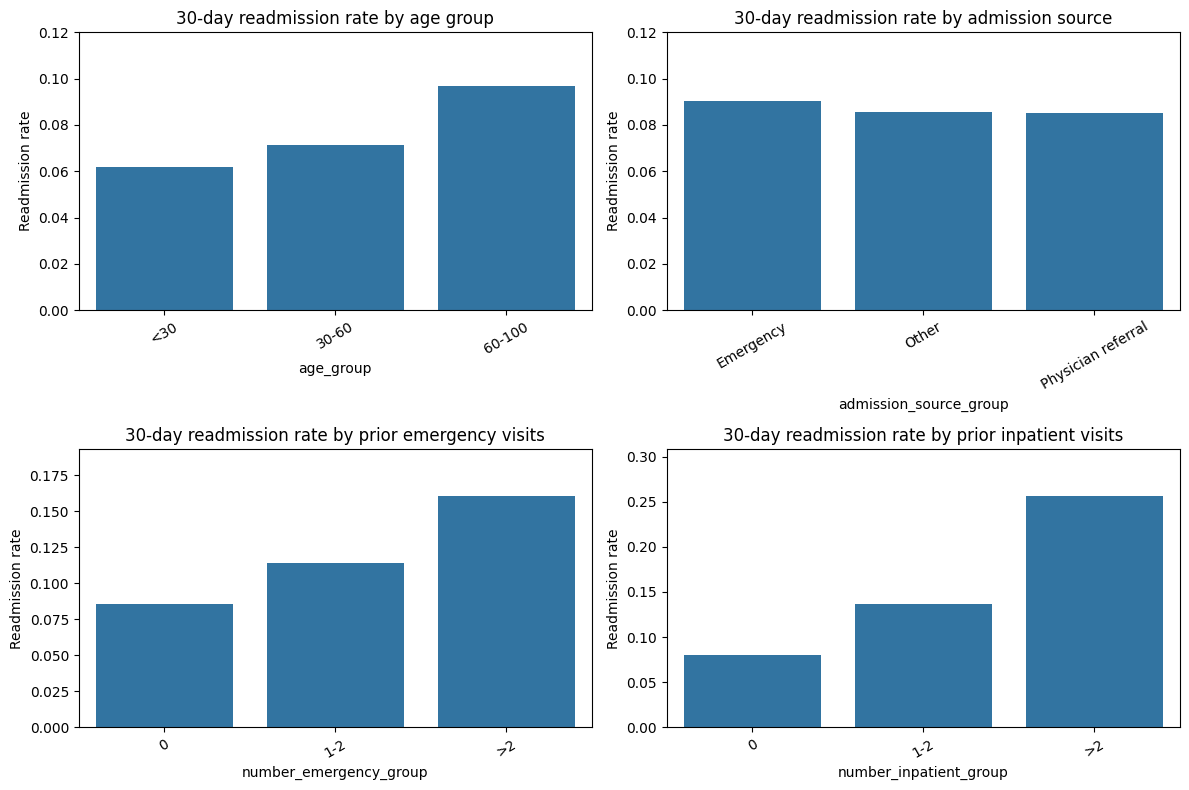

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

eda_df = X_initial_model.copy()
eda_df["readmitted_30"] = y_initial

# Target balance after the initial cleaning steps.
target_summary = eda_df["readmitted_30"].value_counts().rename(
    index={0: "No 30-day readmission", 1: "30-day readmission"}
).to_frame("records")
target_summary["proportion"] = target_summary["records"] / target_summary["records"].sum()
display(target_summary)


def readmission_summary(column):
    return (
        eda_df.groupby(column, observed=True)["readmitted_30"]
        .agg(records="size", readmission_rate="mean")
        .sort_values("readmission_rate", ascending=False)
    )

summary_columns = [
    "age_group",
    "race_group",
    "admission_source_group",
    "diag_1_group",
    "number_outpatient_group",
    "number_emergency_group",
    "number_inpatient_group",
]

for column in summary_columns:
    print(f"Readmission summary by {column}")
    display(readmission_summary(column))

plot_orders = {
    "age_group": ["<30", "30-60", "60-100"],
    "number_outpatient_group": ["0", "1-2", ">2"],
    "number_emergency_group": ["0", "1-2", ">2"],
    "number_inpatient_group": ["0", "1-2", ">2"],
}

plot_specs = [
    ("age_group", "30-day readmission rate by age group"),
    ("admission_source_group", "30-day readmission rate by admission source"),
    ("number_emergency_group", "30-day readmission rate by prior emergency visits"),
    ("number_inpatient_group", "30-day readmission rate by prior inpatient visits"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (column, title) in zip(axes.ravel(), plot_specs):
    summary = readmission_summary(column)
    if column in plot_orders:
        summary = summary.reindex([value for value in plot_orders[column] if value in summary.index])
    summary = summary.reset_index()

    sns.barplot(data=summary, x=column, y="readmission_rate", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Readmission rate")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, max(0.12, summary["readmission_rate"].max() * 1.2))

plt.tight_layout()
plt.show()


In [19]:
# Let's now encode all categorical columns using one-hot encoding.
# For now, let's drop one level from each
# categorical variable to avoid redundant dummy columns.

categorical_columns = [
    "age_group",
    "race_group",
    "gender",
    "admission_type_id",
    "admission_source_group",
    "diag_1_group",
    "number_outpatient_group",
    "number_emergency_group",
    "number_inpatient_group",
]

# Previous numeric approach, kept for reference:
# numeric_columns = [
#     "number_outpatient",
#     "number_emergency",
#     "number_inpatient",
# ]

X_initial_encoded = pd.get_dummies(
    X_initial_model[categorical_columns],
    columns=categorical_columns,
    drop_first=True,
    dtype=int,
)

print(X_initial_model.shape)
print(X_initial_encoded.shape)
display(X_initial_encoded.head())


(71504, 9)
(71504, 29)


,age_group_60-100,age_group_<30,race_group_Caucasian,race_group_Missing,race_group_Other,gender_Male,admission_type_id_2,admission_type_id_3,admission_type_id_4,admission_type_id_5,...,diag_1_group_Musculoskeletal,diag_1_group_Neoplasms,diag_1_group_Other,diag_1_group_Respiratory,number_outpatient_group_1-2,number_outpatient_group_>2,number_emergency_group_1-2,number_emergency_group_>2,number_inpatient_group_1-2,number_inpatient_group_>2
8,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Train test split

For the train-test split, we have to stratify the splitting because the target variable is imbalanced. Only about 10% are re-admitted within 30 days from discharge.


In [20]:
from sklearn.model_selection import train_test_split

# Perform a stratified train-test split to maintain the target variable distribution.
X_train, X_test, y_train, y_test = train_test_split(X_initial_encoded, y_initial, test_size=0.2, random_state=42,
                                                    stratify=y_initial)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(y_train.value_counts(normalize=True).rename("proportion"))
print(y_test.value_counts(normalize=True).rename("proportion"))

(57203, 29) (57203,)
(14301, 29) (14301,)
readmitted_30
0    0.912015
1    0.087985
Name: proportion, dtype: float64
readmitted_30
0    0.912034
1    0.087966
Name: proportion, dtype: float64


## 5. Logistic regression model as a baseline

To start with, we will use the logistic regression model to see how predictive these variables are of readmission.

              precision    recall  f1-score   support

           0       0.93      0.58      0.72     13043
           1       0.11      0.53      0.18      1258

    accuracy                           0.58     14301
   macro avg       0.52      0.56      0.45     14301
weighted avg       0.86      0.58      0.67     14301



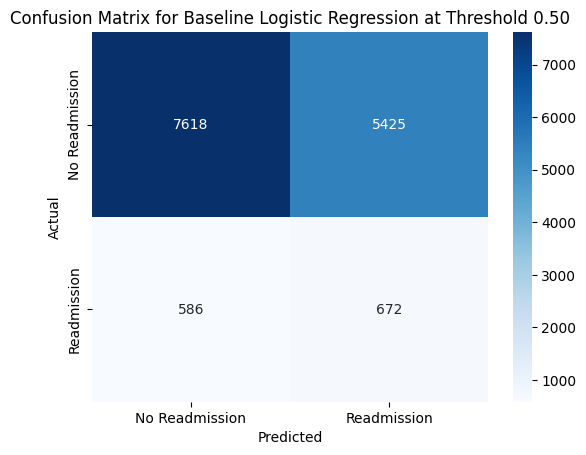

Test ROC-AUC: 0.592
Test average precision: 0.130


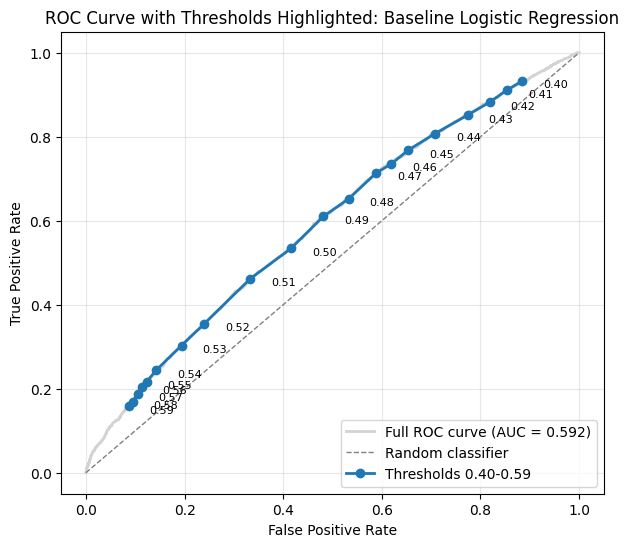

,threshold,fpr,tpr
0,0.40,0.885072,0.933227
1,0.41,0.853638,0.910970
2,0.42,0.818677,0.882353
3,0.43,0.773748,0.851351
4,0.44,0.708043,0.807631
5,0.45,0.653071,0.767886
6,0.46,0.619413,0.735294
7,0.47,0.588668,0.713831
8,0.48,0.533160,0.652623
9,0.49,0.481638,0.610493


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def _positive_class_scores(fitted_model, X):
    """Return continuous positive-class scores and whether they are probabilities."""
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1], True
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X), False
    return None, False


def _plot_confusion_matrix(y_true, y_pred, title, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()
    return cm


def _plot_roc_auc_with_thresholds(
    y_true,
    y_score,
    model_name,
    threshold_values=np.arange(0.4, 0.6, 0.01),
):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    threshold_points = []
    for threshold_value in threshold_values:
        y_pred_at_threshold = (y_score >= threshold_value).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_at_threshold).ravel()
        threshold_points.append(
            {
                "threshold": threshold_value,
                "fpr": fp / (fp + tn),
                "tpr": tp / (tp + fn),
            }
        )

    threshold_points = pd.DataFrame(threshold_points)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color="lightgray", linewidth=2, label=f"Full ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")
    plt.plot(
        threshold_points["fpr"],
        threshold_points["tpr"],
        marker="o",
        color="tab:blue",
        linewidth=2,
        label=f"Thresholds {threshold_values.min():.2f}-{threshold_values.max():.2f}",
    )

    for _, row in threshold_points.iterrows():
        plt.annotate(
            f"{row['threshold']:.2f}",
            (row["fpr"], row["tpr"]),
            textcoords="offset points",
            xytext=(15, -5),
            fontsize=8,
        )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve with Thresholds Highlighted: {model_name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    display(threshold_points)
    return roc_auc, threshold_points


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    *,
    model_name="Model",
    param_grid=None,
    scoring=None,
    cv=5,
    n_jobs=-1,
    threshold=0.50,
    plot_roc_auc=True,
    threshold_values=np.arange(0.4, 0.6, 0.01),
    class_labels=("No Readmission", "Readmission"),
):
    """Fit a classifier, optionally tune it, and print/plot the standard evaluation outputs.

    By default, GridSearchCV uses F1 for the positive readmission class. The ROC-AUC
    chart is optional because it requires continuous scores from predict_proba or
    decision_function.
    """
    scoring = scoring or make_scorer(f1_score, pos_label=1)
    y_train_1d = np.asarray(y_train).ravel()

    pipeline = model if isinstance(model, Pipeline) else Pipeline([("model", model)])

    if param_grid is not None:
        fitted_model = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
        )
    else:
        fitted_model = pipeline

    fitted_model.fit(X_train, y_train_1d)

    if isinstance(fitted_model, GridSearchCV):
        print("Best parameters:", fitted_model.best_params_)
        print("Best cross-validation F1:", fitted_model.best_score_)

    y_score, scores_are_probabilities = _positive_class_scores(fitted_model, X_test)
    if y_score is not None and scores_are_probabilities:
        y_pred = (y_score >= threshold).astype(int)
    else:
        y_pred = fitted_model.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))
    cm = _plot_confusion_matrix(
        y_test,
        y_pred,
        f"Confusion Matrix for {model_name} at Threshold {threshold:.2f}",
        class_labels,
    )

    metrics = {
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
    }

    roc_auc = None
    threshold_points = None
    if y_score is not None:
        roc_auc = roc_auc_score(y_test, y_score)
        metrics["roc_auc"] = roc_auc
        metrics["average_precision"] = average_precision_score(y_test, y_score)
        print(f"Test ROC-AUC: {roc_auc:.3f}")
        print(f"Test average precision: {metrics['average_precision']:.3f}")

        if plot_roc_auc:
            roc_auc, threshold_points = _plot_roc_auc_with_thresholds(
                y_test,
                y_score,
                model_name,
                threshold_values=threshold_values,
            )
    elif plot_roc_auc:
        print("ROC-AUC chart skipped because the fitted model does not provide continuous scores.")

    return {
        "model_name": model_name,
        "estimator": fitted_model,
        "y_pred": y_pred,
        "y_score": y_score,
        "confusion_matrix": cm,
        "metrics": metrics,
        "roc_auc": roc_auc,
        "threshold_points": threshold_points,
    }


baseline_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    C=1,
)

baseline_results = evaluate_model(
    baseline_logistic_model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Baseline Logistic Regression",
)


Best parameters: {'model__C': 0.03, 'model__class_weight': 'balanced', 'model__l1_ratio': 0.0, 'model__max_iter': 5000, 'model__solver': 'saga'}
Best cross-validation F1: 0.1838389319136277
              precision    recall  f1-score   support

           0       0.93      0.57      0.70     13043
           1       0.11      0.55      0.18      1258

    accuracy                           0.56     14301
   macro avg       0.52      0.56      0.44     14301
weighted avg       0.86      0.56      0.66     14301



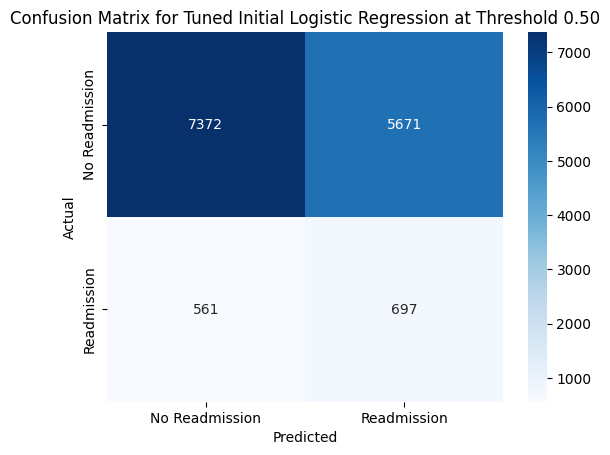

Test ROC-AUC: 0.592
Test average precision: 0.130


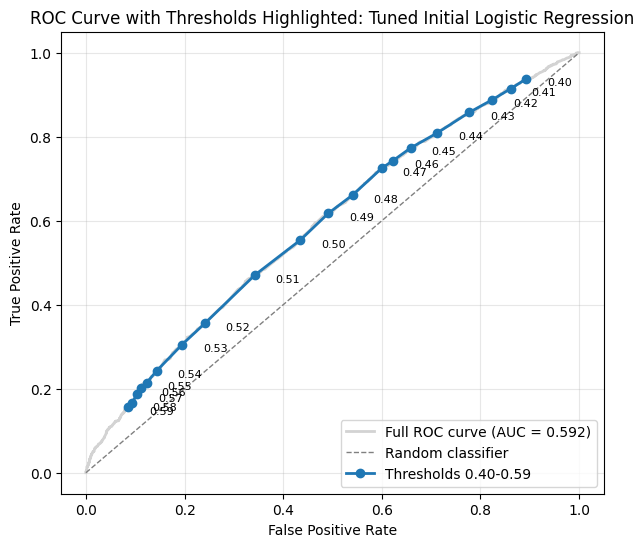

,threshold,fpr,tpr
0,0.40,0.893123,0.937997
1,0.41,0.860998,0.914149
2,0.42,0.823660,0.887917
3,0.43,0.776968,0.857711
4,0.44,0.712566,0.809221
5,0.45,0.658667,0.773450
6,0.46,0.622863,0.743243
7,0.47,0.599709,0.724960
8,0.48,0.540903,0.661367
9,0.49,0.491451,0.617647


In [28]:
# Tune around the balanced logistic-regression baseline.
# F1 is the default GridSearchCV scoring metric inside evaluate_model.
initial_logistic_param_grid = [{
    "model__solver": ["lbfgs"],
    "model__l1_ratio": [0.0],
    "model__C": [0.005, 0.01, 0.015, 0.02, 0.03, 0.05],
    "model__class_weight": ["balanced"],
    "model__max_iter": [2000],
}, {
    "model__solver": ["saga"],
    "model__l1_ratio": [0.0, 0.5, 1.0],
    "model__C": [0.015, 0.02, 0.03, 0.05],
    "model__class_weight": ["balanced"],
    "model__max_iter": [5000],
}]

initial_tuned_results = evaluate_model(
    LogisticRegression(random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Tuned Initial Logistic Regression",
    param_grid=initial_logistic_param_grid,
    plot_roc_auc=True,
)


The model evaluation helper now handles the threshold-dependent confusion matrix and can optionally plot the ROC curve with selected thresholds highlighted. The default decision threshold remains 0.50, and GridSearchCV uses F1 score for the readmission class unless a different scoring function is passed.

In [29]:
# The tuned model call above sets plot_roc_auc=True, so the ROC-AUC chart and
# threshold table are generated as part of the shared evaluation helper.
initial_tuned_results["threshold_points"]


,threshold,fpr,tpr
0,0.40,0.893123,0.937997
1,0.41,0.860998,0.914149
2,0.42,0.823660,0.887917
3,0.43,0.776968,0.857711
4,0.44,0.712566,0.809221
5,0.45,0.658667,0.773450
6,0.46,0.622863,0.743243
7,0.47,0.599709,0.724960
8,0.48,0.540903,0.661367
9,0.49,0.491451,0.617647


ROC-AUC measures how well the model ranks patients by risk. It is useful as a probability-ranking diagnostic, while F1 remains the default model-selection metric because this project evaluates readmission predictions as an imbalanced binary classification task.

## 6. Additional features and further model exploration

The next stage will explore whether HbA1c-related information (`A1Cresult`) and glucose-related information (`max_glu_serum`) improve predictive performance. These variables were excluded from the first admission-focused baseline because it is not clear whether they would be known at the exact time of admission. However, they are central to the project question and to the published paper, so they should be examined in EDA and then considered in an expanded clinical model.

This expanded model should still avoid variables that are only known at discharge, such as `discharge_disposition_id` and `time_in_hospital`, unless the modeling question is explicitly changed to prediction at discharge. The published paper also excluded patients whose discharge status made ordinary readmission analysis inappropriate, including deaths and hospice-related discharges. In the UCI coding scheme, these are commonly represented by discharge disposition IDs `11`, `13`, `14`, `19`, `20`, and `21`. These records should be excluded in a paper-style analysis because patients who died or were discharged to hospice are not comparable to patients who remained at risk for standard hospital readmission.

Therefore, before fitting the next model, the cohort definition should be made explicit: either keep the current first-encounter cohort for admission-time prediction, or additionally remove death and hospice-related discharge dispositions to more closely match the paper-style analysis cohort.

Rows before exclusion: 71,518
Rows after exclusion: 69,973
Rows removed: 1,545


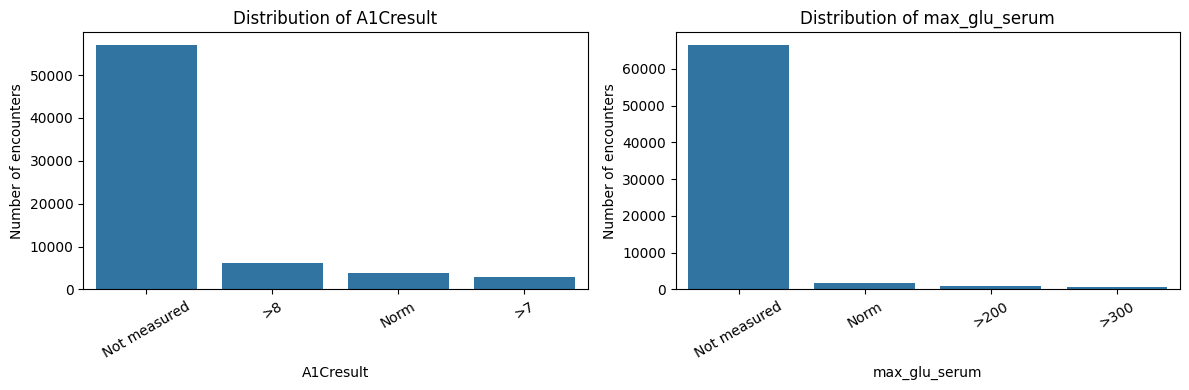

In [30]:
# Remove death and hospice-related discharge dispositions for a paper-style expanded cohort.
# These patients are not comparable to patients who remain at risk for standard readmission.
DEATH_OR_HOSPICE_DISCHARGE_IDS = [11, 13, 14, 19, 20, 21]

df_expanded = df_first.loc[
    ~df_first["discharge_disposition_id"].isin(DEATH_OR_HOSPICE_DISCHARGE_IDS)
].copy()

print(f"Rows before exclusion: {len(df_first):,}")
print(f"Rows after exclusion: {len(df_expanded):,}")
print(f"Rows removed: {len(df_first) - len(df_expanded):,}")

# A1Cresult and max_glu_serum are categorical lab-result variables in this dataset.
# Use count histograms to inspect their distributions.
lab_columns = ["A1Cresult", "max_glu_serum"]
lab_plot_df = df_expanded[lab_columns].fillna("Not measured")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, column in zip(axes, lab_columns):
    order = lab_plot_df[column].value_counts().index
    sns.countplot(data=lab_plot_df, x=column, order=order, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of encounters")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


From the histograms above, we can see that the majority of the patients did not have their HbA1c level measured, and neither did they have the maximum glucose in serum measured. However, those who had, have been categorised, so we have:
- not measured
- normal
- more than 7 but less than 8
- more than 8

Similarly, for glucose, we have:
- not measured normal
- more than 200
- more than 300
This will allow us to create new categorical variables that will be hot encoded for further analysis.

In [31]:
# Build an expanded modeling dataframe with the same engineered variables as before,
# plus HbA1c and serum glucose categories. We rebuild from df_expanded because
# removing death/hospice discharges changes the row set, so appending columns to
# X_initial_encoded could create index-alignment errors.

expanded_feature_columns = [
    "age",
    "race",
    "gender",
    "admission_type_id",
    "admission_source_id",
    "diag_1",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "A1Cresult",
    "max_glu_serum",
]

X_expanded = df_expanded.loc[:, expanded_feature_columns].copy()

# Apply the same row-level cleaning as in the initial model.
X_expanded = X_expanded.loc[X_expanded["gender"].isin(["Male", "Female"])].copy()
X_expanded["race"] = X_expanded["race"].fillna("Missing")
X_expanded = X_expanded.dropna(subset=["diag_1"]).copy()

# Apply the same feature engineering as before.
X_expanded["age_group"] = X_expanded["age"].map(age_group)
X_expanded["race_group"] = X_expanded["race"].map(race_group)
X_expanded["admission_source_group"] = X_expanded["admission_source_id"].map(admission_source_group)
X_expanded["diag_1_group"] = X_expanded["diag_1"].map(diagnosis_group)

for col in ["number_outpatient", "number_emergency", "number_inpatient"]:
    X_expanded[f"{col}_group"] = X_expanded[col].map(utilization_group)

# Keep missing lab results as an explicit category rather than dropping rows.
X_expanded["A1Cresult_group"] = X_expanded["A1Cresult"].fillna("Not measured")
X_expanded["max_glu_serum_group"] = X_expanded["max_glu_serum"].fillna("Not measured")

expanded_model_variables = initial_model_variables + [
    "A1Cresult_group",
    "max_glu_serum_group",
]

X_expanded_model = X_expanded.loc[:, expanded_model_variables].copy()
y_expanded = df_expanded.loc[X_expanded_model.index, "readmitted"].replace({"<30": 1, ">30": 0, "NO": 0})
y_expanded = y_expanded.astype(int)
y_expanded.name = "readmitted_30"

expanded_categorical_columns = categorical_columns + [
    "A1Cresult_group",
    "max_glu_serum_group",
]

X_expanded_encoded = pd.get_dummies(
    X_expanded_model[expanded_categorical_columns],
    columns=expanded_categorical_columns,
    drop_first=True,
    dtype=int,
)

print(X_expanded_model.shape)
print(X_expanded_encoded.shape)
print(y_expanded.shape)
display(X_expanded_model.head())
display(X_expanded_encoded.head())
display(y_expanded.value_counts(normalize=True).rename("proportion"))


(69960, 11)
(69960, 35)
(69960,)


,age_group,race_group,gender,admission_type_id,admission_source_group,diag_1_group,number_outpatient_group,number_emergency_group,number_inpatient_group,A1Cresult_group,max_glu_serum_group
8,60-100,Caucasian,Female,2,Other,Circulatory,0,0,0,Not measured,Not measured
9,60-100,Caucasian,Female,3,Other,Circulatory,0,0,0,Not measured,Not measured
4,30-60,Caucasian,Male,1,Emergency,Neoplasms,0,0,0,Not measured,Not measured
10,30-60,African American,Female,1,Emergency,Diabetes,0,0,0,Not measured,Not measured
5,30-60,Caucasian,Male,2,Other,Circulatory,0,0,0,Not measured,Not measured


,age_group_60-100,age_group_<30,race_group_Caucasian,race_group_Missing,race_group_Other,gender_Male,admission_type_id_2,admission_type_id_3,admission_type_id_4,admission_type_id_5,...,number_emergency_group_1-2,number_emergency_group_>2,number_inpatient_group_1-2,number_inpatient_group_>2,A1Cresult_group_>8,A1Cresult_group_Norm,A1Cresult_group_Not measured,max_glu_serum_group_>300,max_glu_serum_group_Norm,max_glu_serum_group_Not measured
8,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
9,1,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
4,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
5,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


readmitted_30
0    0.910306
1    0.089694
Name: proportion, dtype: float64

Best parameters: {'model__C': 0.026, 'model__class_weight': 'balanced', 'model__l1_ratio': 0.8, 'model__max_iter': 5000, 'model__solver': 'saga'}
Best cross-validation F1: 0.18985224930539496
              precision    recall  f1-score   support

           0       0.93      0.58      0.72     12737
           1       0.11      0.53      0.18      1255

    accuracy                           0.58     13992
   macro avg       0.52      0.56      0.45     13992
weighted avg       0.85      0.58      0.67     13992



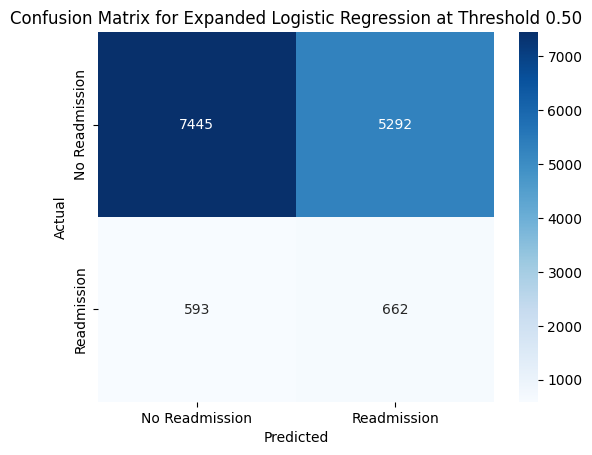

Test ROC-AUC: 0.586
Test average precision: 0.129


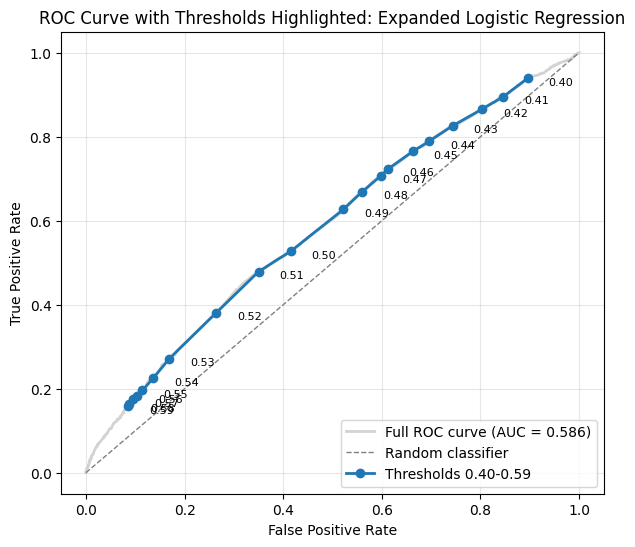

,threshold,fpr,tpr
0,0.40,0.895815,0.939442
1,0.41,0.845725,0.894821
2,0.42,0.803800,0.866135
3,0.43,0.743896,0.826295
4,0.44,0.695454,0.788845
5,0.45,0.662636,0.764940
6,0.46,0.612782,0.723506
7,0.47,0.598728,0.707570
8,0.48,0.560336,0.669323
9,0.49,0.522101,0.627092


In [32]:
# Define a stratified train-test split for the expanded model.

X_train_expanded, X_test_expanded, y_train_expanded, y_test_expanded = train_test_split(
    X_expanded_encoded,
    y_expanded,
    test_size=0.2,
    random_state=42,
    stratify=y_expanded,
)

expanded_logistic_param_grid = [{
    "model__solver": ["lbfgs"],
    "model__l1_ratio": [0.0],
    "model__C": [0.025, 0.03, 0.035, 0.04],
    "model__class_weight": ["balanced"],
    "model__max_iter": [2000],
}, {
    "model__solver": ["saga"],
    "model__l1_ratio": [0.0, 0.7, 0.8, 0.9, 1.0],
    "model__C": [0.025, 0.026, 0.027, 0.028, 0.029],
    "model__class_weight": ["balanced"],
    "model__max_iter": [5000],
}]

expanded_tuned_results = evaluate_model(
    LogisticRegression(random_state=42),
    X_train_expanded,
    y_train_expanded,
    X_test_expanded,
    y_test_expanded,
    model_name="Expanded Logistic Regression",
    param_grid=expanded_logistic_param_grid,
    plot_roc_auc=True,
)
